# 최종 미션 — 파이썬 재현 노트북
파일명을 `미션재현_이름.ipynb`로 바꾸고 시작하세요.

## 이 노트북의 사용법 ⚠️ 중요

**코드는 여러분이 직접 씁니다.** 주석으로 "무엇을 해야 하는지"만 안내되어 있습니다.

```python
# [해야 할 일] 결측이 몇 개인지 확인
# [힌트] 표의 정보를 요약해주는 메서드 (교재 2-3장)
# [결과] 어떤 컬럼에 몇 개인지 보여야 함

여기에 코드 작성  ← 이 자리를 채우는 게 여러분의 일
```

### ⚠️ 미션은 스스로 수행합니다

**코드 작성과 분석 판단은 질문 대상이 아닙니다.** 오늘은 심사가 진행되는 날이며, 이 부분이 평가 대상입니다.

| 구분 | 질문 가능 여부 |
|---|---|
| 미션 요구사항·제출 형식이 이해되지 않을 때 | ✅ 질문 가능 |
| 데이터 컬럼의 의미가 이해되지 않을 때 | ✅ 질문 가능 |
| 실행 환경 오류 (파일 업로드, Colab 접속 등) | ✅ 질문 가능 |
| **코드를 어떻게 쓰는지** | ❌ 스스로 해결 |
| **어떤 그래프를 골라야 하는지** | ❌ 스스로 판단 |
| **기준값을 얼마로 정해야 하는지** | ❌ 스스로 판단 |
| **문법 오류·에러 해결** | ❌ 스스로 해결 |

**막혔을 때 찾아볼 자료** (전부 배포되어 있습니다)

| 상황 | 참조 |
|---|---|
| Orange3로는 했는데 코드를 모르겠다 | 교재 **4-9 로제타석** (Orange3 ↔ 파이썬 대응표) |
| 문법이 기억 안 난다 | 교재 **2장** (pandas 4동작) / 어제 실습 노트북 |
| 위젯 조작이 기억 안 난다 | Orange3 매뉴얼 **STEP 1~16** |
| 분석 흐름이 막막하다 | 어제 저녁 관찰 노트북 **Q1~Q6** |

> 💡 **한 번에 완성하려 하지 마세요.** 한 줄 쓰고 실행 → 결과 보고 → 다음 줄. 에러는 정상이며, 에러를 읽고 고치는 것도 평가 대상입니다.

### 📚 출처 메모 (NASA 저장소에서 확인한 내용을 여기에)
```
어떤 실험인가:리튬이온 배터리 실험.  
다양한 온도에서 충·방전을 수행.
손상 기준으로 임피던스를 기록.
제공 기관:NASA Prognostics Center of Excellence
Citation:B. Saha and K. Goebel (2007). “Battery Data Set”, NASA Prognostics Data Repository, NASA Ames Research Center, Moffett Field, CA

원본 형식 → 배포 형식:.mat -> .csv
```

---
## 준비 — 데이터 불러오기
> 이 셀만 완성되어 있습니다. 나머지는 직접 작성하세요.
> 시작 전: 왼쪽 📁 패널에 `battery_M.csv`와 `battery_NASA.csv`를 모두 드래그 업로드!

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

m = pd.read_csv("/content/battery_M_260722.csv")          # PART 1 · 스냅샷
nasa = pd.read_csv("/content/battery_NASA_260722.csv")    # PART 2 · 시계열

print("M   :", m.shape, "  한 행 = 셀 하나")
print("NASA:", nasa.shape, "  한 행 = 셀 하나의 한 사이클")

M   : (30, 9)   한 행 = 셀 하나
NASA: (636, 11)   한 행 = 셀 하나의 한 사이클


---
# PART 1 — M데이터 (스냅샷)
## 필수 재현 ① · 데이터 확인
> Orange3의 **Column Statistics**로 본 것을 코드로 다시 확인합니다.

In [116]:
# ─────────────────────────────────────────────
# [해야 할 일] 데이터의 앞부분을 눈으로 확인
# [힌트] 표의 첫 몇 줄만 보여주는 메서드
# ─────────────────────────────────────────────
m.head()


,cell_id,cycle_count,initial_capacity,current_capacity,soh,internal_resistance,avg_temp,charge_time,batch_no
0,M01,725,2808.1,2583.5,92.0,32.6,30.1,93,2
1,M02,776,2782.8,2379.3,85.5,38.4,32.5,123,1
2,M03,243,2799.5,2617.5,93.5,39.5,27.1,109,2
3,M04,597,2811.9,2266.4,80.6,42.9,33.9,113,1
4,M05,210,2751.7,2724.2,99.0,28.9,27.2,97,3


In [117]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 컬럼의 타입과 결측(Non-Null) 개수 확인
# [힌트] "출석부 훑기" — 교재 2-3장의 세 버튼 중 두 번째
# [결과] 어떤 컬럼에 결측이 몇 개인지 알 수 있어야 함
# ─────────────────────────────────────────────
m.info()

# ✏️ 확인한 내용 (발표 3·4장 재료):
#    결측 컬럼: current_capacity   개수:3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              30 non-null     object 
 1   cycle_count          30 non-null     int64  
 2   initial_capacity     30 non-null     float64
 3   current_capacity     27 non-null     float64
 4   soh                  30 non-null     float64
 5   internal_resistance  30 non-null     float64
 6   avg_temp             30 non-null     float64
 7   charge_time          30 non-null     int64  
 8   batch_no             30 non-null     int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 2.2+ KB


In [118]:
# ─────────────────────────────────────────────
# [해야 할 일] 수치 컬럼의 요약 통계로 이상한 값 찾기
# [힌트] 세 버튼 중 세 번째. min/max를 유심히 볼 것
# [결과] 물리적으로 불가능한 값이 눈에 띄어야 함
# ─────────────────────────────────────────────
m.describe()

# ✏️ 이상치: 컬럼soh   값121   왜 불가능한가:soh의 최댓값은 100이기 때문에


,cycle_count,initial_capacity,current_capacity,soh,internal_resistance,avg_temp,charge_time,batch_no
count,30.000000,30.000000,27.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,555.266667,2797.073333,2587.214815,93.160000,33.113333,30.850000,100.066667,2.133333
std,221.722867,23.290947,148.545827,7.603747,5.818682,3.680494,10.891102,0.860366
min,152.000000,2751.700000,2266.400000,80.600000,24.000000,23.500000,75.000000,1.000000
25%,372.250000,2782.975000,2478.800000,88.125000,28.550000,28.300000,92.250000,1.000000
50%,593.500000,2798.800000,2592.900000,93.000000,32.250000,31.400000,100.000000,2.000000
75%,716.000000,2808.325000,2712.800000,97.900000,38.550000,33.200000,109.000000,3.000000
max,886.000000,2856.200000,2777.800000,121.000000,42.900000,36.300000,123.000000,3.000000


In [119]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 제외한 데이터를 m_clean 이라는 이름으로 만들기
# [힌트] 조건을 걸어 골라내기 = 마스킹 (교재 1-5, 2-5장)
#        SOH는 100%를 넘을 수 없다
# [결과] print로 제거 전/후 행 수를 비교해 보세요
# ─────────────────────────────────────────────
m_clean = m[m.soh <= 100].dropna()

print("제거 전:", m.shape)
print("제거 후:", m_clean.shape)



제거 전: (30, 9)
제거 후: (26, 9)


## 필수 재현 ② · 최종 판정
> Orange3의 **Select Rows**로 한 선별을 코드로 재현합니다. **두 결과가 같아야 정상입니다.**

In [120]:
# ─────────────────────────────────────────────
# [해야 할 일] 내가 Orange3에서 정한 기준을 조건으로 옮겨 최종 셀 선별
# [힌트] 조건이 2개 이상이면 각각 괄호로 감싸고 & 로 연결
#        df[(조건1) & (조건2)]  ← 괄호 빠뜨리면 에러 (오늘의 1등 에러)
# [결과] 선별된 셀 수를 출력하고, cell_id와 soh를 확인
# ─────────────────────────────────────────────
final = m_clean[(m_clean.soh<=100)&(m_clean.soh>95)]
print(f"선별된 셀 수: {len(final)}개")
print(final[['cell_id', 'soh']])


선별된 셀 수: 10개
   cell_id   soh
4      M05  99.0
6      M07  98.2
7      M08  99.0
8      M09  96.4
12     M13  96.3
14     M15  99.0
15     M16  99.0
19     M20  99.0
24     M25  98.3
28     M29  97.0


In [121]:
# ─────────────────────────────────────────────
# [해야 할 일] Orange3 결과와 일치하는지 대조
# ─────────────────────────────────────────────
# ✏️ Orange3 Select Rows의 Data Out 셀 수:      10개
# ✏️ 파이썬 len(final):                     10개
# ✏️ 일치? 예 / 아니오               예
#    → 아니오라면: 부등호 방향(>= vs >), 기준값, 조건 개수를 하나씩 대조해 보세요


---
# 관문 ① · 기준 민감도 ★변별
### "그 기준, 흔들리면 결과가 얼마나 달라지나요?"

기준값 하나로 판정하고 끝내면 평범합니다. **기준이 얼마나 예민한지 수치로** 보여주세요.

In [122]:
# ─────────────────────────────────────────────
# [해야 할 일] 내 기준값을 -3 / 그대로 / +3 으로 바꿔가며
#              각각 몇 개가 통과하는지 표처럼 출력
#
# [생각해볼 것] 같은 코드를 값만 바꿔 3번 쓰는 것보다,
#               값 목록을 만들어 반복시키는 게 낫지 않을까?
#               (어제 배운 for문 — 리스트를 하나씩 꺼내 쓰기)
#
# [결과 예시]
#   soh >= 82: 통과 26개 / 탈락 3개
#   soh >= 85: 통과 24개 / 탈락 5개
#   soh >= 88: 통과 22개 / 탈락 7개
# ─────────────────────────────────────────────
for i in range(-1,2):
  final = m_clean[(m_clean.soh<=100)&(m_clean.soh>95+i*3)]
  print(f"선별된 셀 수: {len(final)}개")


# ✏️ 발표 7장 문장: "기준을 3%p 낮추면 7개가 더 통과합니다.
#                    그만큼 예민한 경계이므로 95%를 근거로 정했습니다"


선별된 셀 수: 16개
선별된 셀 수: 10개
선별된 셀 수: 7개


In [123]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 내 기준 경계에 아슬아슬하게 걸린 셀 찾기
# [힌트] 기준값 ±2 범위에 있는 셀만 골라내면 됩니다 (조건 2개)
# [왜?] "이 셀은 왜 탈락시켰나요?" 질문에 사례로 답할 수 있습니다
# ─────────────────────────────────────────────
final_boundary = m_clean[(m_clean.soh > 93) & (m_clean.soh <= 97)]
print(f"기준 경계에 아슬아슬하게 걸린 셀 수: {len(final_boundary)}개")
print(final_boundary[['cell_id', 'soh']])


기준 경계에 아슬아슬하게 걸린 셀 수: 6개
   cell_id   soh
2      M03  93.5
8      M09  96.4
12     M13  96.3
13     M14  93.9
16     M17  94.4
28     M29  97.0


---
# 관문 ② · 결측의 영향 ★변별
### "빈칸을 채운 게 답을 바꾸지 않았나요?"

결측을 평균으로 채우고 넘어가면 놓치는 게 있습니다.

In [124]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 결측이 있던 셀들이 어떤 값을 가졌는지 확인
# [힌트] 결측 여부를 판단하는 메서드가 있습니다 (NaN인가?)
#        그 결과를 마스킹 조건으로 쓰면 결측 행만 골라집니다
# [보고 싶은 것] 그 셀들의 cell_id, soh, internal_resistance
# ─────────────────────────────────────────────

missing_capacity_cells = m[m['current_capacity'].isnull()]
print(missing_capacity_cells[['cell_id', 'soh', 'internal_resistance']])

# ✏️ 결측 셀들의 SOH는 합격 경계 근처인가, 확실한 불합격인가?
#합격 경계 근처인 M27셀을 제외한 두개 셀은 확실한 불합격이다.

   cell_id   soh  internal_resistance
5      M06  87.3                 42.8
17     M18  85.1                 41.5
26     M27  94.4                 35.9


In [125]:
# ─────────────────────────────────────────────
# [해야 할 일 2] 결측을 두 가지 방식으로 처리하고 최종 판정을 비교
#   ⓐ 평균으로 채우기  → 내 기준 적용 → 몇 개 통과?
#   ⓑ 해당 행 제외하기 → 내 기준 적용 → 몇 개 통과?
#
# [힌트] 빈칸 채우기 / 빈칸 있는 행 버리기에 해당하는 메서드가 각각 있습니다
#        (교재 4-9 로제타석의 '결측 채우기' 행 참고)
# [결과] 두 방식의 최종 셀 수를 나란히 출력
# ─────────────────────────────────────────────

# 시나리오 ⓐ: current_capacity 결측치를 평균으로 채우고 최종 판정
m_fill_mean = m.copy()
mean_capacity = m_fill_mean['current_capacity'].mean()
m_fill_mean['current_capacity'] = m_fill_mean['current_capacity'].fillna(mean_capacity)

final_fill_mean = m_fill_mean[(m_fill_mean.soh <= 100) & (m_fill_mean.soh > 95)]
count_fill_mean = len(final_fill_mean)
print(f"ⓐ 평균으로 채우기 후 최종 판정 통과 셀 수: {count_fill_mean}개")


# 시나리오 ⓑ: current_capacity 결측치가 있는 행을 제거하고 최종 판정
m_drop_nan = m.copy()
m_drop_nan = m_drop_nan.dropna(subset=['current_capacity'])

final_drop_nan = m_drop_nan[(m_drop_nan.soh <= 100) & (m_drop_nan.soh > 95)]
count_drop_nan = len(final_drop_nan)
print(f"ⓑ 해당 행 제외하기 후 최종 판정 통과 셀 수: {count_drop_nan}개")


# ✏️ 판정이 달라졌는가? 나는 어느 쪽을 택했고 왜인가:
# → 판정 결과는 두 방식 모두 10개로 동일했다. 결측이 있는 행의 soh 값이
#    애초에 판정 구간(95 < soh <= 100)에 들어오지 않아, 처리 방식이 최종
#    통과 셀 수에 영향을 주지 않았기 때문이다.
#
# → 그럼에도 나는 ⓑ 행 제외를 택했다. 이번 데이터에서는 결과가 같았지만,
#    측정되지 않은 셀에 전체 평균 용량을 부여하면 실제로는 열화된 셀이
#    합격 판정을 받을 수 있다. 품질 선별은 안전과 직결되므로, 근거가 없는
#    값을 만들어 넣기보다 판정 대상에서 제외하는 편이 타당하다고 판단했다.

ⓐ 평균으로 채우기 후 최종 판정 통과 셀 수: 10개
ⓑ 해당 행 제외하기 후 최종 판정 통과 셀 수: 10개


---
# 관문 ③ · 함정 회피 ★변별
### "상관 1위가 정말 원인인가요?"

이 데이터에는 **의도적으로 심어둔 함정**이 있습니다. 순위표만 보면 걸립니다.

In [126]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 "제거하기 전(m)"과 "제거한 후(m_clean)"의
#              SOH 상관 순위를 각각 구해서 비교
#
# [힌트] 상관은 corr() — 단, cell_id는 글자라 계산에서 빼야 합니다
#        특정 열을 빼는 방법: drop(columns=[...])
#        SOH 기준 순위만 보려면 결과에서 'soh' 열을 뽑고 정렬
# [결과] 두 순위표를 나란히 출력해 어떤 변수의 순위가 크게 움직였는지 확인
# ─────────────────────────────────────────────

# 제거 전(m) 데이터의 상관 순위
corr_m = m.drop(columns=['cell_id']).corr()
soh_corr_m = corr_m['soh'].sort_values(ascending=False)
print(soh_corr_m)

# 제거 후(m_clean) 데이터의 상관 순위
corr_m_clean = m_clean.drop(columns=['cell_id']).corr()
soh_corr_m_clean = corr_m_clean['soh'].sort_values(ascending=False)
print(soh_corr_m_clean)


soh                    1.000000
current_capacity       0.679110
batch_no               0.411979
initial_capacity       0.027397
cycle_count           -0.210082
avg_temp              -0.216368
charge_time           -0.259754
internal_resistance   -0.446378
Name: soh, dtype: float64
soh                    1.000000
current_capacity       0.991175
batch_no               0.707112
cycle_count           -0.347773
initial_capacity      -0.365579
charge_time           -0.389214
avg_temp              -0.442987
internal_resistance   -0.852061
Name: soh, dtype: float64


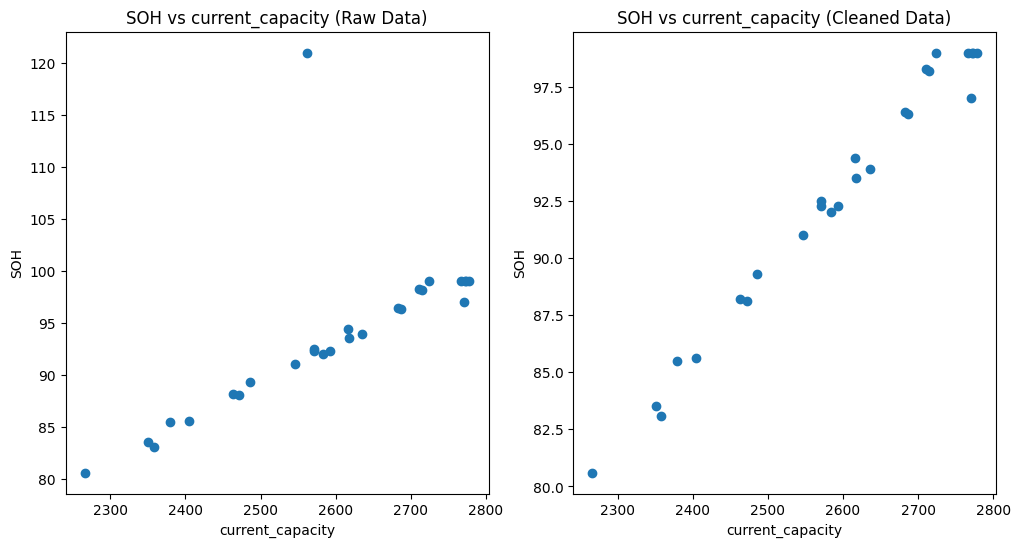

In [127]:
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# [해야 할 일] 의심스러운 변수를 산점도로 다시 확인
# [힌트] 산점도는 plot.scatter(x=..., y=...)
# [따져볼 것] 이 변수가 배터리를 늙게 할 "물리적 이유"가 있는가?
#             (예: 생산 배치 번호가 커지면 배터리가 빨리 늙는다? 말이 되는가?)
# ─────────────────────────────────────────────

# 1. current_capacity 와 soh 의 산점도 (이상치 제거 후 m_clean 데이터 사용)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 플롯
plt.scatter(m['current_capacity'], m['soh'])
plt.title('SOH vs current_capacity (Raw Data)')
plt.xlabel('current_capacity')
plt.ylabel('SOH')

# 2. current_capacity 와 soh 의 산점도 (이상치 제거 후 m_clean 데이터 사용)
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 플롯
plt.scatter(m_clean['current_capacity'], m_clean['soh'])
plt.title('SOH vs current_capacity (Cleaned Data)')
plt.xlabel('current_capacity')
plt.ylabel('SOH')

plt.show()


# ✏️ 첫 번째 산점도 변수: current_capacity     물리적으로 타당한가? 예 (사이클 수가 늘면 SOH가 낮아지는 것이 상식적)
# ✏️ 함정으로 의심되는 변수: batch_no              배제 이유: 생산 배치 번호는 SOH의 물리적인 노화와 직접적인 관련이 없으므로, 높은 상관관계는 우연일 가능성이 크거나 다른 숨겨진 요인이 있을 수 있음. 특히 이상치 제거 후 상관성이 증가한 것이 의심스러움.

---
# PART 2 — NASA 데이터 (시계열)
## 2단계 · 데이터 확인

In [128]:
# ─────────────────────────────────────────────
# [해야 할 일] NASA 데이터의 구조 파악 — 앞부분 + 결측 확인
# [주목] 결측이 있다면 어느 컬럼에, 몇 개나?
# ─────────────────────────────────────────────

nasa.info()
nasa.head()
nasa.describe()
nasa_clean=nasa[nasa.soh <= 100].dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              636 non-null    object 
 1   cycle_count          636 non-null    int64  
 2   ambient_temp         636 non-null    int64  
 3   capacity             636 non-null    float64
 4   soh                  636 non-null    float64
 5   internal_resistance  579 non-null    float64
 6   avg_temp             636 non-null    float64
 7   max_temp             636 non-null    float64
 8   discharge_time       636 non-null    float64
 9   min_voltage          636 non-null    float64
 10  is_eol               636 non-null    int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 54.8+ KB


In [129]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 셀마다 사이클 수가 다른지 확인
# [힌트] 셀별로 묶어서(groupby) 각 그룹의 최대 사이클을 보면 됩니다
# [왜?] 셀마다 관측 길이가 다르면 비교할 때 주의해야 합니다 (발표 '한계' 재료)
# ─────────────────────────────────────────────

print(nasa_clean.groupby('cell_id').size())
# ─────────────────────────────────────────────
# [해야 할 일 2 · 관문② 심화] 결측이 어디에 있는지 확인 ★
# [힌트] 결측인 행만 골라낸 뒤, 셀별·사이클별로 어디에 몰려 있는지 보세요
#        (groupby로 묶어 min/max 사이클을 보면 구간이 드러납니다)
# [따져볼 것] 결측이 무작위인가, 특정 구간에 몰려 있는가?
#             몰려 있다면 평균으로 채우는 게 왜 위험한가?
# ─────────────────────────────────────────────
# 1) 결측(internal_resistance가 NaN)인 행만 남기기
nullcell = nasa[nasa['internal_resistance'].isnull()]

# 2) cell_id로 묶어, 각 그룹의 cycle_count 최소값·최대값을 원래 행 길이에 맞춰 붙이기
min_cycles = nullcell.groupby('cell_id')[['cycle_count', 'internal_resistance']].min().reset_index()
max_cycles = nullcell.groupby('cell_id')[['cycle_count', 'internal_resistance']].max().reset_index()

# 최소값과 최대값을 합쳐서 'edge' 변수에 저장
edge = pd.concat([min_cycles, max_cycles]).sort_values(['cell_id', 'cycle_count'])

print("\n결측 구간의 시작/끝 행 (셀별 최소·최대 사이클):")
print(edge[['cell_id', 'cycle_count', 'internal_resistance']].sort_values(['cell_id', 'cycle_count']))


# ✏️ 결측 구간: B0005, B0006, B0007 셀 모두 1사이클부터 19사이클까지의 'internal_resistance' 값
# 평균 대체가 위험한 이유: 결측치가 무작위가 아니라 초반 구간에 집중적으로 발생하여 결측치를 평균으로 대체할 시 자료해석에 오류가 생길 수 있다

cell_id
B0005    149
B0006    149
B0007    149
B0018    132
dtype: int64

결측 구간의 시작/끝 행 (셀별 최소·최대 사이클):
  cell_id  cycle_count  internal_resistance
0   B0005            1                  NaN
0   B0005           19                  NaN
1   B0006            1                  NaN
1   B0006           19                  NaN
2   B0007            1                  NaN
2   B0007           19                  NaN


## 3단계 · 열화 곡선 그리기 ★ 오늘의 핵심 그래프
> Orange3에서는 산점도로 봤지만, 파이썬에서는 **진짜 선 그래프**를 그릴 수 있습니다.

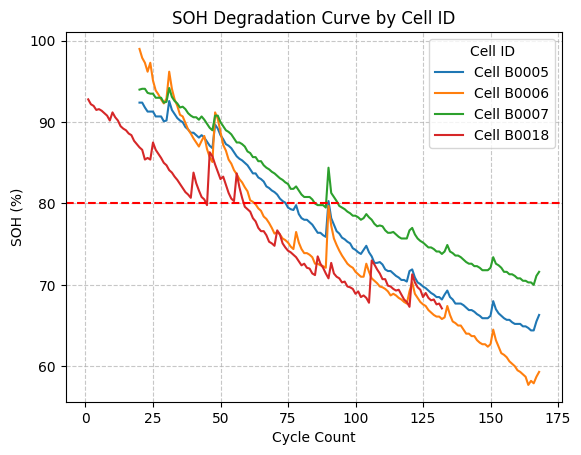

In [130]:
# ─────────────────────────────────────────────
# [해야 할 일] 셀마다 선을 하나씩 그려서, 사이클에 따른 SOH 변화 표시
#
# [설계 힌트]
#   1) 셀별로 데이터를 나눠야 한다 → groupby로 묶으면 (이름, 데이터) 쌍이 나옵니다
#   2) 각 셀마다 선을 하나씩 → plt.plot(x축값, y축값, label=셀이름)
#   3) EOL 기준선 80%를 가로선으로 → plt.axhline(80, color='red', linestyle='--')
#   4) 범례·축 이름 → plt.legend(), plt.xlabel(), plt.ylabel()
#   5) 마지막에 plt.show()
#
# [결과] 왼쪽 위에서 오른쪽 아래로 흘러내리는 곡선 4개 + 빨간 기준선
# ─────────────────────────────────────────────


# 셀별로 데이터를 묶어서 그래프 그리기
for cell_id, cell_data in nasa_clean.groupby('cell_id'):
    plt.plot(cell_data['cycle_count'], cell_data['soh'], label=f'Cell {cell_id}')

# EOL 기준선 80% 표시
plt.axhline(80, color='red', linestyle='--')

# 범례, 축 이름, 제목 설정
plt.legend(title='Cell ID')
plt.xlabel('Cycle Count')
plt.ylabel('SOH (%)')
plt.title('SOH Degradation Curve by Cell ID')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ✏️ 이 그림에서 알게 된 것 한 문장 (발표 8장): 각 셀의 SOH는 사이클 수 증가에 따라 점진적으로 감소하며, 각 셀이 EOL(80% SOH)에 도달하는 시점(사이클 수)이 다름을 알 수 있습니다.

In [131]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 셀이 몇 번째 사이클에 EOL(SOH 80% 미만)에 도달했는지
# [힌트] EOL 여부를 나타내는 컬럼이 이미 있습니다 (is_eol)
#        그 값이 1인 행만 고른 뒤, 셀별로 묶어서 가장 작은 사이클을 찾으면 됩니다
# [결과] 셀 4개의 EOL 도달 사이클
# ─────────────────────────────────────────────
eolcell = nasa_clean[(nasa_clean['is_eol']==1)]

eol_cycle_counts = eolcell.groupby('cell_id')['cycle_count'].min()
print(eol_cycle_counts)

# ✏️ 가장 빨리 죽은 셀: B0018      가장 오래 버틴 셀: B0007          차이: 41      사이클

cell_id
B0005    75
B0006    63
B0007    86
B0018    45
Name: cycle_count, dtype: int64


---
# 관문 ④ · 교차 검증 ★변별
### "PART 1의 발견이 PART 2에서도 성립하나요?"

두 데이터를 따로 분석하고 끝내면 절반입니다. **연결**하세요.

In [132]:
# ─────────────────────────────────────────────
# [해야 할 일] PART 1에서 찾은 열화 신호(변수)가
#              NASA 데이터에서도 같은 방향인지 상관으로 확인
#
# [힌트] 두 데이터 각각에서 해당 변수와 soh의 상관계수를 구해 나란히 출력
# [따져볼 것] 방향(+/-)은 같은가? 강도는? 왜 차이가 날까?
# ─────────────────────────────────────────────


corr_nasa_clean = nasa_clean.drop(columns=['cell_id']).corr()
soh_corr_nasa_clean = corr_nasa_clean['soh'].sort_values(ascending=False)
print(soh_corr_nasa_clean)


corr_m_clean = m_clean.drop(columns=['cell_id']).corr()
soh_corr_m_clean = corr_m_clean['soh'].sort_values(ascending=False)
print(soh_corr_m_clean)
# ✏️ M데이터 상관: current_capacity (0.991175)          NASA 상관: capacity (0.999996)
# ✏️ 나의 해석 (발표 9장): M데이터와 NASA 데이터 모두 SOH와 용량 관련 변수(current_capacity, capacity)가 매우 높은 양의 상관관계를 보였습니다. 이는 배터리 건강 상태가 용량 감소와 밀접하게 관련되어 있음을 의미합니다.

soh                    1.000000
capacity               0.999995
discharge_time         0.949398
min_voltage           -0.224830
avg_temp              -0.562011
max_temp              -0.569375
internal_resistance   -0.712684
is_eol                -0.854369
cycle_count           -0.912468
ambient_temp                NaN
Name: soh, dtype: float64
soh                    1.000000
current_capacity       0.991175
batch_no               0.707112
cycle_count           -0.347773
initial_capacity      -0.365579
charge_time           -0.389214
avg_temp              -0.442987
internal_resistance   -0.852061
Name: soh, dtype: float64


In [133]:

# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별로 나눠서 본 상관 vs 전체를 한 덩어리로 본 상관 ★
# [힌트] groupby로 셀을 나눈 뒤, 각 그룹에서 저항-SOH 상관을 구해 비교
# [따져볼 것] 셀마다 값이 크게 다른가? 전체 상관과 차이가 나는가?
#             다르다면 "평균의 함정"일 수 있습니다
# ─────────────────────────────────────────────

print("--- 개별 셀의 internal_resistance와 soh 상관관계 ---")
cell_soh_ir_correlations = {}

for cell_id, group_df in nasa_clean.groupby('cell_id'):
    g = group_df.dropna(subset=['internal_resistance', 'soh'])
    correlation = g['internal_resistance'].corr(g['soh'])
    cell_soh_ir_correlations[cell_id] = correlation
    print(f"Cell {cell_id}: {correlation:.4f}")

print("\n--- 전체 NASA 데이터의 internal_resistance와 soh 상관관계 ---")
overall_nasa_ir_soh_corr = soh_corr_nasa_clean.get('internal_resistance', float('nan'))
print(f"전체 NASA 데이터: {overall_nasa_ir_soh_corr:.4f}")
# ✏️ 나의 해석: 셀 B0018을 제외한 나머지 셀의 soh와 내부저항의 상관관계는 비슷하였다. 이를통해 평균의 오류가 일어났음을 알 수 있다.

# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별 열화 속도(기울기) 비교
# [힌트] (첫 SOH - 마지막 SOH) / 사이클 수, 또는 numpy polyfit으로 직선 맞추기
# ─────────────────────────────────────────────
for cell_id, group_df in nasa_clean.groupby('cell_id'):
    g = group_df.dropna(subset=['cycle_count', 'soh']).sort_values('cycle_count')
    slope = (g['soh'].iloc[0] - g['soh'].iloc[-1]) / (g['cycle_count'].iloc[-1] - g['cycle_count'].iloc[0])
    print(f"Cell {cell_id}: {slope:.5f}")

--- 개별 셀의 internal_resistance와 soh 상관관계 ---
Cell B0005: -0.9291
Cell B0006: -0.9825
Cell B0007: -0.9615
Cell B0018: -0.5588

--- 전체 NASA 데이터의 internal_resistance와 soh 상관관계 ---
전체 NASA 데이터: -0.7127
Cell B0005: 0.17635
Cell B0006: 0.26824
Cell B0007: 0.15135
Cell B0018: 0.19618


---
# 4단계 · 결론·한계 메모
발표 9~10장에 쓸 내용을 여기에 정리하세요.

In [134]:
결론 = """
1. SOH와 가장 상관관계가 큰것은 capacity(용량)이다.
2. 실질적으로 열화시키는 변수는 internal_resistance(내부저항)다. 이는 SOH와 음의 상관관계를 이루며 내부저항이 열화와 밀접한 관계가 있음을 알 수 있다.
3. batch_no는 열화와 관련이 없다.
4. 판정 기준을 SOH 95%로 설정시, 10개 셀이 만족했다(Orange3 Select Rows 결과와 일치).
   기준을 3%p 낮추면 만족하는 셀 수가 크게 늘어나는 예민한 경계이므로 근거를 명시했다.
5. NASA 4개 셀의 EOL 도달 사이클은 B0018이 가장 빠르고 B0007이 가장 늦어 41사이클 차이가 났다.
   동일 조건 셀 간에도 수명 편차가 크다.
"""

한계_3가지 = """
1. 평균의 함정
전체 데이터를 기준으로 보면 저항과 SOH의 상관계수는 -0.713이지만, 셀별로는 B0006: -0.983 ~ B0018: -0.559로 차이가 크게 나타난다. 따라서 전체 상관계수 하나만으로 개별 셀의 특성을 판단하기는 어렵다. 또한 셀마다 열화 속도(기울기)가 달라 하나의 모델로 모든 셀을 일반화하는 데 한계가 있다.

2. 결측치가 무작위가 아님 — NASA 데이터의 internal_resistance 결측은 B0005·B0006·B0007의 1~19사이클 초기 구간에 집중되어 있어 무작위 결측(MNAR)이 아니다. 이를 평균값으로 대체하면 초기 저항이 실제보다 높게 추정되어 열화 추세가 실제보다 완만하게 보일 수 있다. 또한 M 데이터의 current_capacity 결측 3건 중 1건(M27)은 합격 기준 경계에 위치해 있어, 결측 처리 방식에 따라 판정 결과가 달라질 가능성이 있다.

3. 표본과 실험 조건의 한계 — NASA 데이터는 셀이 4개뿐이며, 셀마다 관측된 사이클 수가 달라 동일한 기준에서 직접 비교하기 어렵다.

"""

print(결론); print(한계_3가지)


1. SOH와 가장 상관관계가 큰것은 capacity(용량)이다.
2. 실질적으로 열화시키는 변수는 internal_resistance(내부저항)다. 이는 SOH와 음의 상관관계를 이루며 내부저항이 열화와 밀접한 관계가 있음을 알 수 있다.
3. batch_no는 열화와 관련이 없다.
4. 판정 기준을 SOH 95%로 설정시, 10개 셀이 만족했다(Orange3 Select Rows 결과와 일치).
   기준을 3%p 낮추면 만족하는 셀 수가 크게 늘어나는 예민한 경계이므로 근거를 명시했다.
5. NASA 4개 셀의 EOL 도달 사이클은 B0018이 가장 빠르고 B0007이 가장 늦어 41사이클 차이가 났다.
   동일 조건 셀 간에도 수명 편차가 크다.


1. 평균의 함정
전체 데이터를 기준으로 보면 저항과 SOH의 상관계수는 -0.713이지만, 셀별로는 B0006: -0.983 ~ B0018: -0.559로 차이가 크게 나타난다. 따라서 전체 상관계수 하나만으로 개별 셀의 특성을 판단하기는 어렵다. 또한 셀마다 열화 속도(기울기)가 달라 하나의 모델로 모든 셀을 일반화하는 데 한계가 있다.

2. 결측치가 무작위가 아님 — NASA 데이터의 internal_resistance 결측은 B0005·B0006·B0007의 1~19사이클 초기 구간에 집중되어 있어 무작위 결측(MNAR)이 아니다. 이를 평균값으로 대체하면 초기 저항이 실제보다 높게 추정되어 열화 추세가 실제보다 완만하게 보일 수 있다. 또한 M 데이터의 current_capacity 결측 3건 중 1건(M27)은 합격 기준 경계에 위치해 있어, 결측 처리 방식에 따라 판정 결과가 달라질 가능성이 있다.

3. 표본과 실험 조건의 한계 — NASA 데이터는 셀이 4개뿐이며, 셀마다 관측된 사이클 수가 달라 동일한 기준에서 직접 비교하기 어렵다.




---
## 제출 전 확인

- [ ] **런타임 → 모두 실행** 후 저장 (실행 결과가 남아 있어야 합니다)
- [ ] 필수 재현 ②의 셀 수가 Orange3 결과와 일치
- [ ] 열화 곡선 그래프가 그려졌다
- [ ] 관문 ①~④ 중 시도한 것에 ✏️ 메모를 채웠다
- [ ] 파일명이 `미션재현_이름.ipynb`

> **제출 마감: 23:00** — 파일 → 다운로드 → `.ipynb` 다운로드 후 안내 채널에 업로드

> 완성하지 못한 관문이 있어도 괜찮습니다. **시도한 흔적(코드와 메모)이 남아 있으면 부분 점수**를 받습니다.